# 4. Visualização de Dados e Análise


In [2]:
# Extração da base de dados e insights modularizados com 'processing.py'
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
from src.processing import (load_clean_and_process,
                            revenue_by_category,
                            top_products_by_quantity,
                            daily_sales)

df = load_clean_and_process('../data/raw_data.csv')
df.head()

Inicializando limpeza dos dados...
Dados limpos com sucesso!


,ID_Pedido,Data_Compra,Cliente_ID,Produto,Categoria,Quantidade,Preco_Unitario,Status_Entrega,Total_Venda
0,1001,2026-06-25,109,Smartwatch,Eletrônicos,1.0,5999.9,Cancelado,5999.9
1,1002,2026-06-13,135,Smartwatch,Eletrônicos,3.0,8500.0,Entregue,25500.0
2,1003,2026-06-05,113,Smartwatch,Acessórios,3.0,799.5,Entregue,2398.5
3,1004,2026-06-20,130,Smartwatch,Acessórios,4.0,2100.0,Entregue,8400.0
4,1005,2026-06-25,147,Smartwatch,Acessórios,4.0,850.0,Cancelado,3400.0


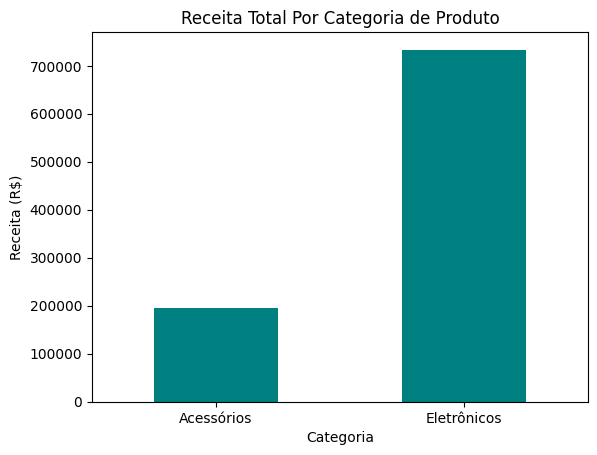

In [3]:
# Gráfico 1: Receita por Categoria
receita_por_categoria = revenue_by_category(df) # Uso da função que retorna uma Series com dados prontos para plotagem

receita_por_categoria.plot(kind = 'bar', color = 'teal')
plt.title('Receita Total Por Categoria de Produto')
plt.ylabel('Receita (R$)')
plt.xlabel('Categoria')
plt.xticks(rotation = 0)
plt.show()

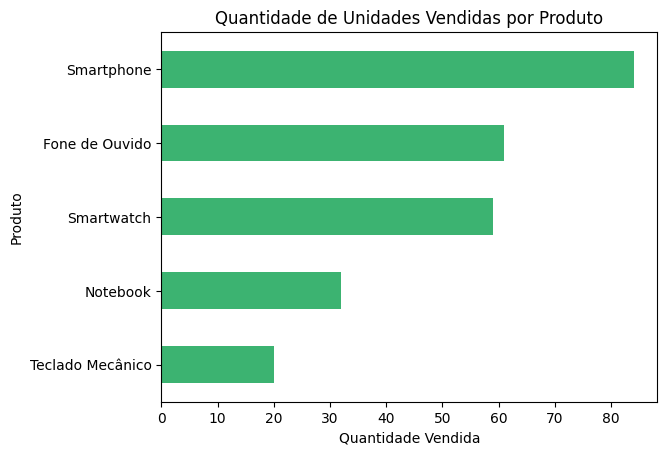

In [4]:
# Gráfico 2: Quantidade Vendida por Produto
produto_mais_vendido = top_products_by_quantity(df)

produto_mais_vendido.plot(kind='barh', color='mediumseagreen')
plt.title('Quantidade de Unidades Vendidas por Produto')
plt.ylabel('Produto')
plt.xlabel('Quantidade Vendida')
plt.gca().invert_yaxis()
plt.show()

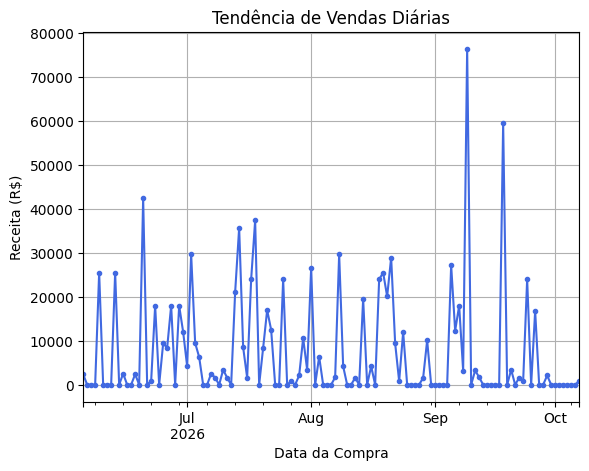

In [5]:
# Gráfico 3: Tendência de Vendas ao Longo do Tempo
vendas_por_dia = daily_sales(df)

vendas_por_dia.plot(kind = 'line', marker = '.', linestyle = '-', color='royalblue')
plt.title('Tendência de Vendas Diárias')
plt.ylabel('Receita (R$)')
plt.xlabel('Data da Compra')
plt.grid(True)
plt.show()

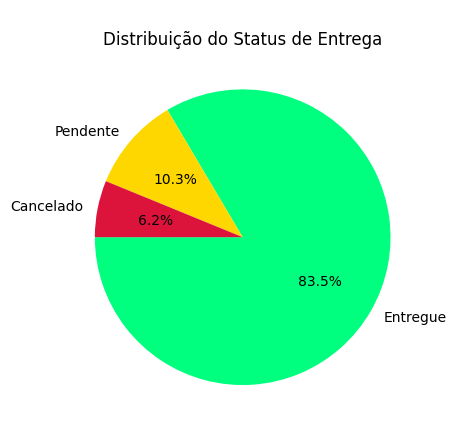

In [6]:
# Gráfico 4: Distribuição do Status de Entrega
status_entrega_count = df['Status_Entrega'].value_counts()

plt.pie(
    status_entrega_count,                 # Valores numéricos para cada fatia (quantidade de cada status)
    labels = status_entrega_count.index,  # Rótulos de cada fatia (labels dos status)
    autopct = '%1.1f%%',           # Mostra o percentual em cada fatia com 1 casa decimal
    startangle = 180,              # Ângulo inicial para "girar" o gráfico e escolher onde começa a primeira fatia
    colors = ['springgreen',        # Cor da primeira fatia
              'gold',            # Cor da segunda fatia
              'crimson']        # Cor da terceira fatia


)

plt.title('\nDistribuição do Status de Entrega')
plt.show()